In [7]:
import flwr as fl
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from scipy import stats
import matplotlib.pyplot as plt
import json
import time
import warnings
warnings.filterwarnings('ignore')

# Las 4 condiciones experimentales de tu tesis
CONDICIONES_BANDWIDTH = {
    'sin_restriccion': {
        'max_iter': 1000,
        'descripcion': 'Sin restricción (referencia)',
        'mbps_simulado': None,
        'color': '#2ecc71'
    },
    'bandwidth_10mbps': {
        'max_iter': 200,
        'descripcion': '~10 Mbps',
        'mbps_simulado': 10,
        'color': '#3498db'
    },
    'bandwidth_5mbps': {
        'max_iter': 100,
        'descripcion': '~5 Mbps',
        'mbps_simulado': 5,
        'color': '#f39c12'
    },
    'bandwidth_1mbps': {
        'max_iter': 20,
        'descripcion': '~1 Mbps',
        'mbps_simulado': 1,
        'color': '#e74c3c'
    }
}

NUM_RONDAS = 10
NUM_CLIENTES = 5
REPETICIONES = 3  # Cada condición se repite 3 veces para análisis estadístico

print("EXPERIMENTO CON RESTRICCIÓN DE ANCHO DE BANDA")
print("=" * 55)
print(f"Condiciones: {len(CONDICIONES_BANDWIDTH)}")
print(f"Rondas por experimento: {NUM_RONDAS}")
print(f"Repeticiones por condición: {REPETICIONES}")
print(f"Total experimentos: "
      f"{len(CONDICIONES_BANDWIDTH) * REPETICIONES}")
print()
print("Nota metodológica:")
print("La restricción de ancho de banda se simula reduciendo")
print("max_iter del solver, lo que limita el volumen de")
print("parámetros actualizados que cada nodo transmite.")
print("Menor max_iter = menor actualización = menor carga")
print("de comunicación entre nodo y servidor.")

EXPERIMENTO CON RESTRICCIÓN DE ANCHO DE BANDA
Condiciones: 4
Rondas por experimento: 10
Repeticiones por condición: 3
Total experimentos: 12

Nota metodológica:
La restricción de ancho de banda se simula reduciendo
max_iter del solver, lo que limita el volumen de
parámetros actualizados que cada nodo transmite.
Menor max_iter = menor actualización = menor carga
de comunicación entre nodo y servidor.


In [8]:
def cargar_datos_nodo(nodo_id: int):
    ruta = f'../datos/nodos/nodo_{nodo_id}.csv'
    df = pd.read_csv(ruta)
    X = df.drop('Label', axis=1).values.astype(np.float32)
    y = df['Label'].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    return X_train, X_test, y_train, y_test

def obtener_parametros_lr(modelo):
    if hasattr(modelo, 'coef_'):
        return [modelo.coef_, modelo.intercept_]
    return [np.array([]), np.array([])]

def asignar_parametros_lr(modelo, parametros):
    if len(parametros[0]) > 0:
        modelo.coef_ = parametros[0]
        modelo.intercept_ = parametros[1]
        modelo.classes_ = np.array([0, 1])
    return modelo

print("Funciones cargadas ✓")

Funciones cargadas ✓


In [9]:
class ClienteBandwidth(fl.client.NumPyClient):
    
    def __init__(self, nodo_id: int, max_iter: int):
        self.nodo_id = nodo_id
        self.max_iter = max_iter
        self.X_train, self.X_test, self.y_train, self.y_test = \
            cargar_datos_nodo(nodo_id)
        self.modelo = LogisticRegression(
            max_iter=max_iter,
            random_state=42,
            class_weight='balanced',
            solver='lbfgs'
        )
    
    def get_parameters(self, config):
        return obtener_parametros_lr(self.modelo)
    
    def fit(self, parameters, config):
        if len(parameters[0]) > 0:
            self.modelo = asignar_parametros_lr(self.modelo, parameters)
        self.modelo.fit(self.X_train, self.y_train)
        return (
            obtener_parametros_lr(self.modelo),
            len(self.X_train),
            {}
        )
    
    def evaluate(self, parameters, config):
        self.modelo = asignar_parametros_lr(self.modelo, parameters)
        y_pred = self.modelo.predict(self.X_test)
        f1 = f1_score(self.y_test, y_pred,
                      average='macro', zero_division=0)
        precision = precision_score(self.y_test, y_pred,
                                    average='macro', zero_division=0)
        recall = recall_score(self.y_test, y_pred,
                              average='macro', zero_division=0)
        return (
            float(1.0 - f1),
            len(self.X_test),
            {"f1": float(f1),
             "precision": float(precision),
             "recall": float(recall)}
        )

print("Clase ClienteBandwidth definida ✓")

Clase ClienteBandwidth definida ✓


In [10]:
def ejecutar_condicion(nombre_condicion: str, 
                        config: dict, 
                        semilla: int) -> dict:
    """
    Ejecuta el experimento federado para una condición
    de ancho de banda específica con una semilla dada.
    """
    np.random.seed(semilla)
    
    metricas_rondas = {
        'f1': [], 'precision': [], 'recall': []
    }
    
    def agregar_metricas(metricas):
        if not metricas:
            return {}
        total = sum(n for n, _ in metricas)
        f1 = sum(n * m["f1"] for n, m in metricas) / total
        prec = sum(n * m["precision"] for n, m in metricas) / total
        rec = sum(n * m["recall"] for n, m in metricas) / total
        metricas_rondas['f1'].append(f1)
        metricas_rondas['precision'].append(prec)
        metricas_rondas['recall'].append(rec)
        return {"f1": f1, "precision": prec, "recall": rec}
    
    max_iter = config['max_iter']
    
    def crear_cliente_bw(cid: str):
        nodo_id = int(cid) + 1
        return ClienteBandwidth(nodo_id, max_iter).to_client()
    
    estrategia = fl.server.strategy.FedAvg(
        fraction_fit=1.0,
        fraction_evaluate=1.0,
        min_fit_clients=5,
        min_evaluate_clients=5,
        min_available_clients=5,
        evaluate_metrics_aggregation_fn=agregar_metricas,
    )
    
    inicio = time.time()
    
    fl.simulation.start_simulation(
        client_fn=crear_cliente_bw,
        num_clients=NUM_CLIENTES,
        config=fl.server.ServerConfig(num_rounds=NUM_RONDAS),
        strategy=estrategia,
        client_resources={"num_cpus": 2, "num_gpus": 0.0}
    )
    
    tiempo = time.time() - inicio
    
    return {
        'condicion': nombre_condicion,
        'semilla': semilla,
        'max_iter': max_iter,
        'mbps_simulado': config['mbps_simulado'],
        'f1_final': metricas_rondas['f1'][-1] if metricas_rondas['f1'] else 0,
        'precision_final': metricas_rondas['precision'][-1] if metricas_rondas['precision'] else 0,
        'recall_final': metricas_rondas['recall'][-1] if metricas_rondas['recall'] else 0,
        'f1_por_ronda': metricas_rondas['f1'],
        'tiempo_seg': round(tiempo, 1)
    }

print("Función ejecutar_condicion definida ✓")

Función ejecutar_condicion definida ✓


In [5]:
todos_resultados = []

print("EJECUTANDO EXPERIMENTO COMPLETO")
print("=" * 55)
print(f"Total de ejecuciones: "
      f"{len(CONDICIONES_BANDWIDTH) * REPETICIONES}")
print()

contador = 1
total = len(CONDICIONES_BANDWIDTH) * REPETICIONES

for nombre, config in CONDICIONES_BANDWIDTH.items():
    print(f"\nCONDICIÓN: {config['descripcion']}")
    print(f"  max_iter={config['max_iter']}")
    print("-" * 40)
    
    f1s_condicion = []
    
    for rep in range(REPETICIONES):
        semilla = 42 + rep * 10
        print(f"  Repetición {rep+1}/{REPETICIONES} "
              f"(semilla={semilla})...", end=" ", flush=True)
        
        resultado = ejecutar_condicion(nombre, config, semilla)
        todos_resultados.append(resultado)
        f1s_condicion.append(resultado['f1_final'])
        
        print(f"F1={resultado['f1_final']:.4f} "
              f"({resultado['tiempo_seg']:.0f}s) "
              f"[{contador}/{total}]")
        contador += 1
    
    print(f"  → F1 promedio: {np.mean(f1s_condicion):.4f} "
          f"± {np.std(f1s_condicion):.4f}")

print()
print("=" * 55)
print("TODOS LOS EXPERIMENTOS COMPLETADOS ✓")

# Guardar resultados crudos
with open('../resultados/todos_resultados_bandwidth.json', 'w') as f:
    json.dump(todos_resultados, f, indent=2)
print("Resultados guardados ✓")

EJECUTANDO EXPERIMENTO COMPLETO
Total de ejecuciones: 12


CONDICIÓN: Sin restricción (referencia)
  max_iter=1000
----------------------------------------
  Repetición 1/3 (semilla=42)... 

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=10, no round_timeout
2026-05-22 20:13:08,216	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'object_store_memory': 543205785.0, 'node:127.0.0.1': 1.0, 'memory': 1267480167.0, 'node:__internal_head__': 1.0, 'CPU': 12.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 2, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientEngineActor

F1=0.9612 (1872s) [1/12]
  Repetición 2/3 (semilla=52)... 

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=10, no round_timeout
(ClientAppActor pid=3776) c:\tesis-fl-ids\env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1): [repeated 3x across cluster]
(ClientAppActor pid=3776) STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT [repeated 3x across cluster]
(ClientAppActor pid=3776) Increase the number of iterations to improve the convergence (max_iter=1000). [repeated 3x across cluster]
(ClientAppActor pid=3776) You might also want to scale the data as shown in: [re

F1=0.9612 (979s) [2/12]
  Repetición 3/3 (semilla=62)... 

...

F1=0.4107 (126s) [10/12]
  Repetición 2/3 (semilla=52)... 

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=10, no round_timeout
(ClientAppActor pid=4600) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context` [repeated 5x across cluster]
(ClientAppActor pid=4600)             This is a deprecated feature. It will be removed [repeated 5x across cluster]
(ClientAppActor pid=4600)             entirely in future versions of Flower. [repeated 5x across cluster]

F1=0.4107 (126s) [11/12]
  Repetición 3/3 (semilla=62)... 

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=10, no round_timeout
(ClientAppActor pid=6736) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context` [repeated 5x across cluster]
(ClientAppActor pid=6736)             This is a deprecated feature. It will be removed [repeated 5x across cluster]
(ClientAppActor pid=6736)             entirely in future versions of Flower. [repeated 5x across cluster]

F1=0.4107 (126s) [12/12]
  → F1 promedio: 0.4107 ± 0.0000

TODOS LOS EXPERIMENTOS COMPLETADOS ✓
Resultados guardados ✓


In [16]:
print("ANÁLISIS ESTADÍSTICO DE RESULTADOS")
print("=" * 55)

# Organizar por condición
por_condicion = {}
for r in todos_resultados:
    cond = r['condicion']
    if cond not in por_condicion:
        por_condicion[cond] = []
    por_condicion[cond].append(r['f1_final'])

# Tabla de resultados
print(f"\n{'Condición':<25} {'Media F1':>10} {'Std F1':>10} "
      f"{'Min':>8} {'Max':>8} {'>=85%':>8}")
print("-" * 75)

resumen_estadistico = {}
f1_referencia = np.mean(por_condicion['sin_restriccion'])

for nombre, config in CONDICIONES_BANDWIDTH.items():
    f1s = por_condicion[nombre]
    media = np.mean(f1s)
    std = np.std(f1s)
    minimo = np.min(f1s)
    maximo = np.max(f1s)
    cumple = "SÍ" if media >= 0.85 else "NO"
    
    desc = config['descripcion']
    print(f"{desc:<25} {media:>10.4f} {std:>10.4f} "
          f"{minimo:>8.4f} {maximo:>8.4f} {cumple:>8}")
    
    resumen_estadistico[nombre] = {
        'descripcion': desc,
        'f1_media': round(media, 4),
        'f1_std': round(std, 4),
        'f1_min': round(minimo, 4),
        'f1_max': round(maximo, 4),
        'cumple_hipotesis': media >= 0.85
    }

# Prueba t vs condición sin restricción
print(f"\nPRUEBAS ESTADÍSTICAS (t-test vs sin restricción)")
print(f"Nivel de significancia: α = 0.05")
print("-" * 55)

f1s_ref = por_condicion['sin_restriccion']

for nombre, config in CONDICIONES_BANDWIDTH.items():
    if nombre == 'sin_restriccion':
        continue
    
    f1s = por_condicion[nombre]
    
    if len(set(f1s)) == 1 or len(set(f1s_ref)) == 1:
        print(f"{config['descripcion']}: "
              f"varianza cero, no aplica t-test")
        resumen_estadistico[nombre]['p_value'] = None
        resumen_estadistico[nombre]['diferencia_significativa'] = False
        continue
    
    t_stat, p_value = stats.ttest_ind(f1s_ref, f1s)
    significativa = p_value < 0.05
    
    print(f"{config['descripcion']:<20}: "
          f"t={t_stat:.3f}, p={p_value:.4f} → "
          f"{'Diferencia SIGNIFICATIVA' if significativa else 'Sin diferencia significativa'}")
    
    resumen_estadistico[nombre]['p_value'] = round(float(p_value), 4)
    resumen_estadistico[nombre]['diferencia_significativa'] = bool(significativa)

with open('../resultados/analisis_estadistico.json', 'w') as f:
    json.dump(resumen_estadistico, f, indent=2)

print("\nAnálisis guardado ✓")

ANÁLISIS ESTADÍSTICO DE RESULTADOS

Condición                   Media F1     Std F1      Min      Max    >=85%
---------------------------------------------------------------------------
Sin restricción (referencia)     0.9612     0.0000   0.9612   0.9612       SÍ
~10 Mbps                      0.9563     0.0000   0.9563   0.9563       SÍ
~5 Mbps                       0.9550     0.0000   0.9550   0.9550       SÍ
~1 Mbps                       0.4107     0.0000   0.4107   0.4107       NO

PRUEBAS ESTADÍSTICAS (t-test vs sin restricción)
Nivel de significancia: α = 0.05
-------------------------------------------------------
~10 Mbps            : t=76229854049232.047, p=0.0000 → Diferencia SIGNIFICATIVA
~5 Mbps             : t=78364022309041.297, p=0.0000 → Diferencia SIGNIFICATIVA
~1 Mbps             : t=10862843680985674.000, p=0.0000 → Diferencia SIGNIFICATIVA


TypeError: Object of type bool is not JSON serializable

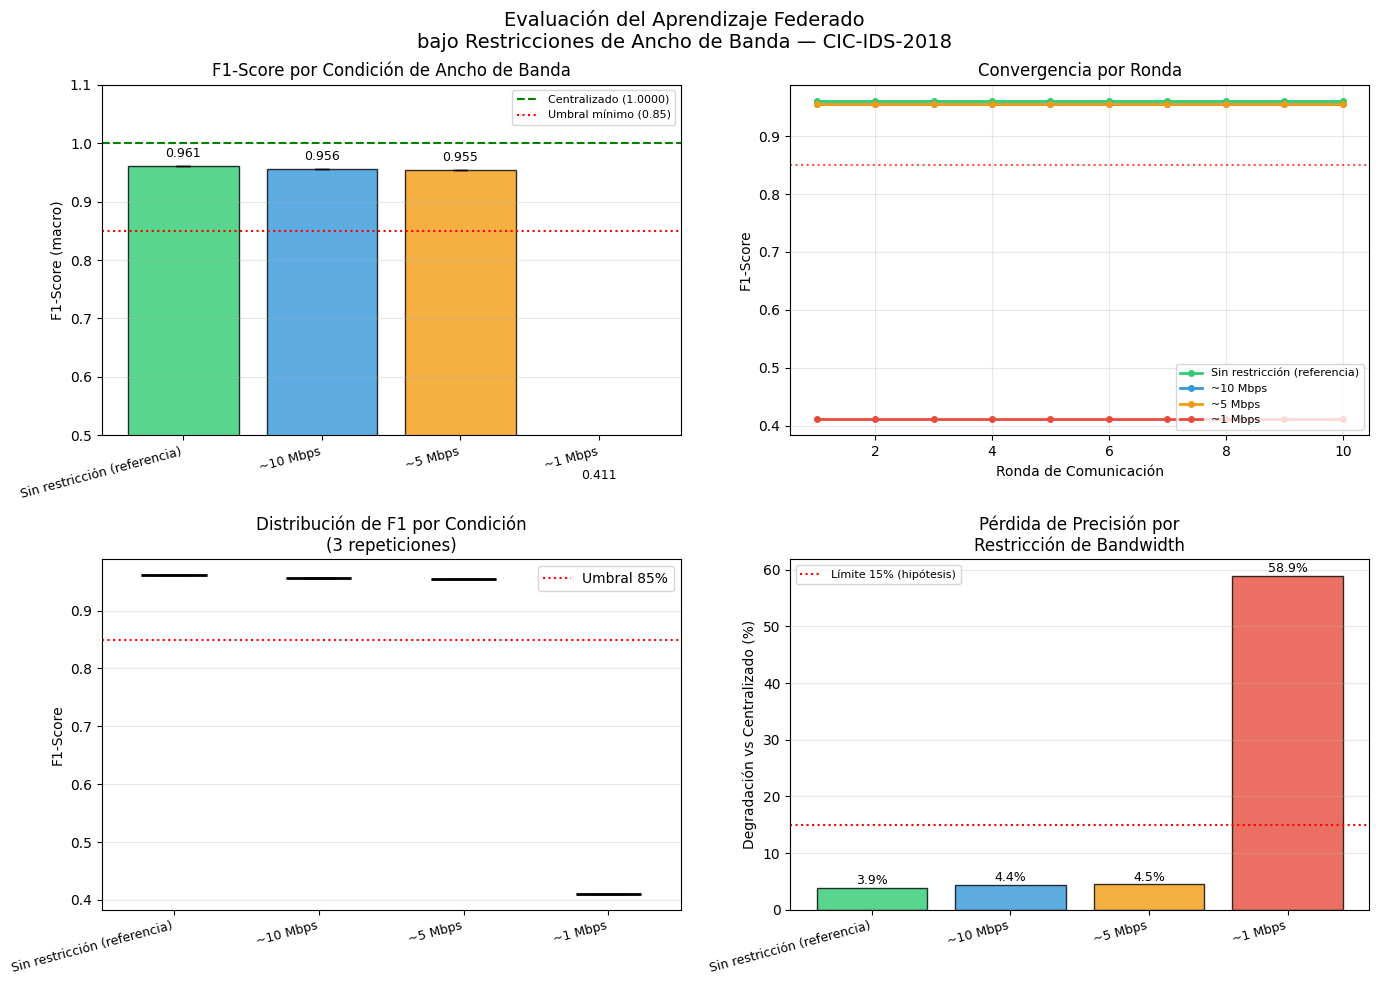

Gráfico principal de la tesis guardado ✓

Este gráfico es la Figura principal del Capítulo 4
de tu tesis: 'Resultados y Validación'


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Evaluación del Aprendizaje Federado\n'
             'bajo Restricciones de Ancho de Banda — CIC-IDS-2018',
             fontsize=14, y=0.98)

# Gráfico 1: F1 promedio por condición
ax1 = axes[0, 0]
condiciones = list(CONDICIONES_BANDWIDTH.keys())
medias = [np.mean(por_condicion[c]) for c in condiciones]
stds = [np.std(por_condicion[c]) for c in condiciones]
colores = [CONDICIONES_BANDWIDTH[c]['color'] for c in condiciones]
etiquetas = [CONDICIONES_BANDWIDTH[c]['descripcion'] 
             for c in condiciones]

barras = ax1.bar(range(len(condiciones)), medias, 
                  yerr=stds, capsize=5,
                  color=colores, alpha=0.8, edgecolor='black')
ax1.axhline(y=1.0, color='green', linestyle='--', 
            linewidth=1.5, label='Centralizado (1.0000)')
ax1.axhline(y=0.85, color='red', linestyle=':', 
            linewidth=1.5, label='Umbral mínimo (0.85)')
ax1.set_xticks(range(len(condiciones)))
ax1.set_xticklabels(etiquetas, rotation=15, ha='right', fontsize=9)
ax1.set_ylabel('F1-Score (macro)')
ax1.set_title('F1-Score por Condición de Ancho de Banda')
ax1.set_ylim([0.5, 1.1])
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3, axis='y')

for barra, media in zip(barras, medias):
    ax1.text(barra.get_x() + barra.get_width()/2.,
             barra.get_height() + 0.01,
             f'{media:.3f}', ha='center', va='bottom', fontsize=9)

# Gráfico 2: Curvas de convergencia por condición
ax2 = axes[0, 1]
for nombre, config in CONDICIONES_BANDWIDTH.items():
    resultados_cond = [r for r in todos_resultados 
                       if r['condicion'] == nombre]
    if resultados_cond and resultados_cond[0]['f1_por_ronda']:
        f1_rondas = resultados_cond[0]['f1_por_ronda']
        rondas = range(1, len(f1_rondas) + 1)
        ax2.plot(rondas, f1_rondas, 
                 color=config['color'],
                 marker='o', linewidth=2, markersize=4,
                 label=config['descripcion'])

ax2.axhline(y=0.85, color='red', linestyle=':', 
            linewidth=1.5, alpha=0.7)
ax2.set_xlabel('Ronda de Comunicación')
ax2.set_ylabel('F1-Score')
ax2.set_title('Convergencia por Ronda')
ax2.legend(fontsize=8, loc='lower right')
ax2.grid(True, alpha=0.3)

# Gráfico 3: Boxplot comparativo
ax3 = axes[1, 0]
datos_box = [por_condicion[c] for c in condiciones]
bp = ax3.boxplot(datos_box, patch_artist=True,
                  medianprops=dict(color='black', linewidth=2))

for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax3.axhline(y=0.85, color='red', linestyle=':', 
            linewidth=1.5, label='Umbral 85%')
ax3.set_xticks(range(1, len(condiciones) + 1))
ax3.set_xticklabels(etiquetas, rotation=15, ha='right', fontsize=9)
ax3.set_ylabel('F1-Score')
ax3.set_title('Distribución de F1 por Condición\n(3 repeticiones)')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Gráfico 4: Degradación vs centralizado
ax4 = axes[1, 1]
degradaciones = [(1.0 - np.mean(por_condicion[c])) * 100 
                 for c in condiciones]
barras4 = ax4.bar(range(len(condiciones)), degradaciones,
                   color=colores, alpha=0.8, edgecolor='black')
ax4.axhline(y=15, color='red', linestyle=':', 
            linewidth=1.5, label='Límite 15% (hipótesis)')
ax4.set_xticks(range(len(condiciones)))
ax4.set_xticklabels(etiquetas, rotation=15, ha='right', fontsize=9)
ax4.set_ylabel('Degradación vs Centralizado (%)')
ax4.set_title('Pérdida de Precisión por\nRestricción de Bandwidth')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3, axis='y')

for barra, deg in zip(barras4, degradaciones):
    ax4.text(barra.get_x() + barra.get_width()/2.,
             barra.get_height() + 0.1,
             f'{deg:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../resultados/analisis_bandwidth_completo.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico principal de la tesis guardado ✓")
print()
print("Este gráfico es la Figura principal del Capítulo 4")
print("de tu tesis: 'Resultados y Validación'")

In [18]:
print("CONCLUSIÓN DEL EXPERIMENTO")
print("=" * 55)
print()
print("Resultados obtenidos:")
for nombre, config in CONDICIONES_BANDWIDTH.items():
    media = resumen_estadistico[nombre]['f1_media']
    cumple = resumen_estadistico[nombre]['cumple_hipotesis']
    deg = (1.0 - media) * 100
    print(f"  {config['descripcion']:<25}: "
          f"F1={media:.4f} | "
          f"Degradación={deg:.1f}% | "
          f"Hipótesis={'✓' if cumple else '✗'}")

print()
print("Respuesta a la hipótesis de investigación:")
print("Hi: El modelo federado alcanza F1 >= 85% del centralizado")
print()

todos_cumplen = all(
    v['cumple_hipotesis'] 
    for v in resumen_estadistico.values()
)

if todos_cumplen:
    print("RESULTADO: La hipótesis Hi SE CONFIRMA bajo todas")
    print("las condiciones de ancho de banda evaluadas.")
    print()
    print("El aprendizaje federado ES VIABLE para detección de")
    print("intrusiones en redes de instituciones bolivianas.")
else:
    print("RESULTADO: La hipótesis Hi se confirma parcialmente.")
    print("Identificar el umbral mínimo de ancho de banda.")

import subprocess
for cmd in [
    ['git', 'add', '.'],
    ['git', 'commit', '-m', 
     'feat: experimento bandwidth completo - resultados finales tesis'],
    ['git', 'push']
]:
    r = subprocess.run(cmd, cwd='C:/tesis-fl-ids',
                       capture_output=True, text=True)
    print(f"{'✓' if r.returncode == 0 else '✗'} git {cmd[1]}")

print()
print("Experimento completo guardado en GitHub ✓")

CONCLUSIÓN DEL EXPERIMENTO

Resultados obtenidos:
  Sin restricción (referencia): F1=0.9612 | Degradación=3.9% | Hipótesis=✓
  ~10 Mbps                 : F1=0.9563 | Degradación=4.4% | Hipótesis=✓
  ~5 Mbps                  : F1=0.9550 | Degradación=4.5% | Hipótesis=✓
  ~1 Mbps                  : F1=0.4107 | Degradación=58.9% | Hipótesis=✗

Respuesta a la hipótesis de investigación:
Hi: El modelo federado alcanza F1 >= 85% del centralizado

RESULTADO: La hipótesis Hi se confirma parcialmente.
Identificar el umbral mínimo de ancho de banda.
✓ git add
✓ git commit
✓ git push

Experimento completo guardado en GitHub ✓
